In [5]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 


In [6]:
df=pd.read_csv("Rajshahi-Srimongals.csv")

In [7]:
df.describe()

,Unnamed: 0,Year,Month,Date,ST-10,ST-30,ST-50,Temperature
count,16070.000000,16070.000000,16070.000000,16070.000000,16070.000000,16070.000000,16070.000000,16070.000000
mean,8034.500000,2011.500311,6.523522,15.728811,27.192778,27.485732,27.181801,25.014396
std,4639.153748,6.344094,3.448821,8.800017,4.770993,4.401427,4.058129,4.854033
min,0.000000,2001.000000,1.000000,1.000000,14.300000,15.600000,15.550000,8.500000
25%,4017.250000,2006.000000,4.000000,8.000000,23.200000,23.900000,23.800000,21.200000
50%,8034.500000,2012.000000,7.000000,16.000000,28.800000,29.100000,28.565000,26.600000
75%,12051.750000,2017.000000,10.000000,23.000000,31.000000,31.060000,30.500000,28.800000
max,16069.000000,2022.000000,12.000000,31.000000,38.000000,36.800000,36.300000,34.800000


In [8]:
dff=df.copy()

In [9]:


data_raj=dff[dff['Region']=='Rajshahi']
data_sri=dff[dff['Region']=='Srimongal']


In [10]:
df_raj=data_raj[['Temperature', 'ST-10', 'ST-30', 'ST-50']]
df_sri=data_sri[['Temperature', 'ST-10', 'ST-30', 'ST-50']]

In [6]:
df_sri.sample()

,Temperature,ST-10,ST-30,ST-50
5524,22.0,23.3,22.7,22.4


# Rajshahi Linear Regression

In [11]:
import math 



n=len(df_raj)

train_end=math.floor(n*0.80)


train_raj=df_raj.iloc[:train_end]
val_raj=df_raj.iloc[train_end:]

X_train_raj=train_raj[['Temperature']]
y_train_raj=train_raj[['ST-30']]

X_val_raj=val_raj[['Temperature']]
y_val_raj=val_raj[['ST-30']]


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error


In [13]:
lr_raj=LinearRegression()
lr_raj.fit(X_train_raj,y_train_raj)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
y_raj_pred=lr_raj.predict(X_val_raj)
mae_raj=round(mean_absolute_error(y_val_raj,y_raj_pred),3)
mse_raj=mean_squared_error(y_val_raj,y_raj_pred)
rmse_raj=round(mse_raj**0.5,3)
r2_raj=round(r2_score(y_val_raj,y_raj_pred),2)


print("\nRAJSHAHI\n")
print(f"MAE: {mae_raj}\nRMSE: {rmse_raj}\nR2 SCORE: {r2_raj}")


RAJSHAHI

MAE: 1.054
RMSE: 1.385
R2 SCORE: 0.91


In [14]:
m_raj=lr_raj.coef_[0][0]
m_raj

0.9080534937625948

In [15]:
c_raj=lr_raj.intercept_[0]
c_raj

4.760889338135787

In [16]:
y_val_raj.shape

(1607, 1)

C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_11372\2140514160.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot([y_val_raj.min(), y_val_raj.max()],


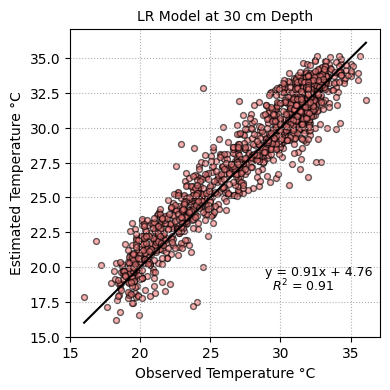

In [74]:
y_val_rajj= y_val_raj[400:1200]
y_raj_predd = y_raj_pred[400:1200]
plt.figure(figsize=(4,4))
plt.scatter(y_val_raj, y_raj_pred,s=18, c='#f57e7e', alpha=0.6, edgecolors='black',marker='o')
plt.plot([y_val_raj.min(), y_val_raj.max()],
         [y_val_raj.min(), y_val_raj.max()],
         'r-', lw=1.5, label="1:1 line",c='black')

x_vals = np.linspace(y_val_raj.min(), y_val_raj.max(), 100)
#plt.plot(x_vals, m_raj * x_vals + c_raj, 'b-', lw=2, label="Best fit line",c='#320d3e')

plt.text(0.63, 0.2, f'y = {m_raj:.2f}x + {c_raj:.2f}', transform=plt.gca().transAxes, fontsize=9)
plt.text(0.65, 0.15, f'$R^2$ = {r2_raj:.2f}', transform=plt.gca().transAxes, fontsize=9)

plt.xlabel('Observed Temperature °C', fontsize=10)
plt.ylabel('Estimated Temperature °C', fontsize=10)
plt.title('LR Model at 30 cm Depth', fontsize=10)
plt.grid(ls=':')
plt.show()

# Srimongal Linear Regression 

In [18]:
import math

m = len(df_sri)

train_end_sri = math.floor(m * 0.80)

train_sri = df_sri.iloc[:train_end_sri]
val_sri = df_sri.iloc[train_end_sri:]


In [19]:
val_sri.shape

(1607, 4)

In [20]:
X_train_sri = train_sri[['Temperature']]
y_train_sri = train_sri[['ST-30']]

X_val_sri = val_sri[['Temperature']]
y_val_sri = val_sri[['ST-30']]



In [21]:
Q1 = X_train_sri['Temperature'].quantile(0.25)
Q3 = X_train_sri['Temperature'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
X_train_sri['Temperature'] = X_train_sri['Temperature'].clip(lower=lower_bound, upper=upper_bound)


C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_8200\970763780.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_sri['Temperature'] = X_train_sri['Temperature'].clip(lower=lower_bound, upper=upper_bound)


In [22]:
X_train_sri.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6428 entries, 0 to 6427
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  6428 non-null   float64
dtypes: float64(1)
memory usage: 100.4 KB


In [23]:
lr_sri = LinearRegression()
lr_sri.fit(X_train_sri, y_train_sri)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
y_sri_pred=lr_sri.predict(X_val_sri)
mae_sri=round(mean_absolute_error(y_val_sri,y_sri_pred),3)
mse_sri=mean_squared_error(y_val_sri,y_sri_pred)
rmse_sri=round(mse_sri**0.5,3)
r2_sri=round(r2_score(y_val_sri,y_sri_pred),2)


print("\nSRIMONGAL\n")
print(f"MAE: {mae_sri}\nRMSE: {rmse_sri}\nR2 SCORE: {r2_sri}")


SRIMONGAL

MAE: 0.984
RMSE: 1.285
R2 SCORE: 0.9


In [25]:
m_sri=lr_sri.coef_[0][0]
m_sri

0.8359526029386042

In [26]:
c_sri=lr_sri.intercept_[0]
c_sri

6.746767797291113

C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_8200\116583248.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot([y_val_sri.min(), y_val_sri.max()],


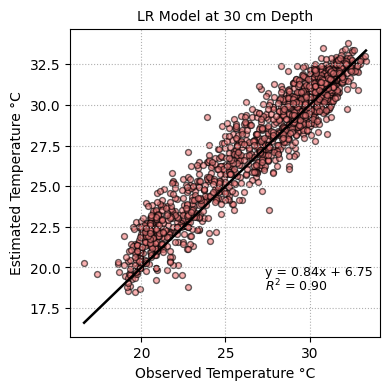

In [27]:

plt.figure(figsize=(4,4))
plt.scatter(y_val_sri, y_sri_pred,s=18, c='#f57e7e', alpha=0.6, edgecolors='black',marker='o')
plt.plot([y_val_sri.min(), y_val_sri.max()],
         [y_val_sri.min(), y_val_sri.max()],
         'r-', lw=1.8, label="1:1 line",c='BLACK')

x_vals_sri = np.linspace(y_val_sri.min(), y_val_sri.max(), 100)
#plt.plot(x_vals_sri, m_sri * x_vals_sri + c_sri, 'b-', lw=2, label="Best fit line" ,c='#320d3e')

plt.text(0.63, 0.2, f'y = {m_sri:.2f}x + {c_sri:.2f}', transform=plt.gca().transAxes, fontsize=9)
plt.text(0.63, 0.15, f'$R^2$ = {r2_sri:.2f}', transform=plt.gca().transAxes, fontsize=9)

plt.xlabel('Observed Temperature °C', fontsize=10)
plt.ylabel('Estimated Temperature °C', fontsize=10)
plt.title('LR Model at 30 cm Depth', fontsize=10)
plt.grid(ls=':')
plt.show()
